# Extracting Data from the Title Page of an ODOT Drawing Set

In [1]:
# Import necessary libraries
from civilpy.state.ohio.DOT.title_sheet import process_document, export_for_review
from PIL import Image
from IPython.display import display, Image as IPImage
import matplotlib.pyplot as plt

In [2]:
# Define the paths to the various resources
path_to_text_file = r"C:\Users\dparks1\OneDrive - State of Ohio\Desktop\example_plans\ODOT Sample Plans.pdf"
path_to_image_file = r"C:\Users\dparks1\OneDrive - State of Ohio\Desktop\example_plans\20813-001.tif"
MODEL_PATH = "trained_model.pth"
TARGET_LABEL = "Standard Construction Drawings" # The section you want to extract

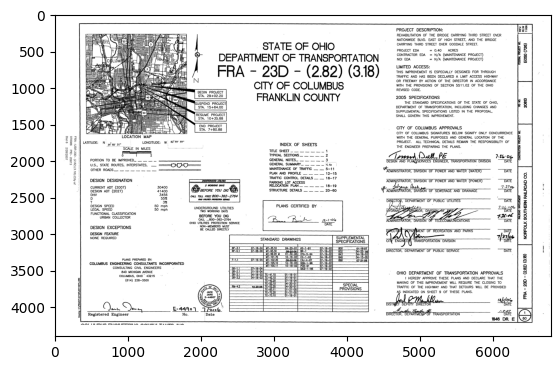

In [3]:
# Display the Title sheet we're working with
img = Image.open(path_to_image_file)

plt.imshow(img)

In [4]:
# Example of the output when processing a "text" based, CADD-generated pdf
text_results = process_document(MODEL_PATH, path_to_text_file, TARGET_LABEL, page_number=3)

Using device: cuda
Model loaded successfully!
--- Processing PDF: C:\Users\dparks1\OneDrive - State of Ohio\Desktop\example_plans\ODOT Sample Plans.pdf ---
Found 'Standard Construction Drawings' with confidence 0.9697

Attempting table extraction in area: 730.9485473632812,356.7325439453125,1437.9122314453125,0.0 on page 3
✅ Camelot found a table. PDF is likely text-based in this region.


In [5]:
# Example of the output when processing an "image" based scanned pdf
results = process_document(MODEL_PATH, path_to_image_file, TARGET_LABEL)

Using device: cuda
Model loaded successfully!
--- Processing Image: C:\Users\dparks1\OneDrive - State of Ohio\Desktop\example_plans\20813-001.tif ---
Found 'Standard Construction Drawings' with confidence 0.9940
ℹ️ Input is an image. Bypassing Camelot for direct structured OCR.
🤖 Starting structured OCR on image...
✅ OCR successfully extracted a table with 24 rows and 9 columns.


In [6]:
# Export the results of the extraction to excel for the user to review
export_for_review(results)

🧹 Pre-cleaning raw OCR data before exporting to Excel...

------------------------------
✨ Exporting pre-cleaned data for manual review...

--- OUTPUTS FOR REVIEW ---
🖼️  Image:      C:\Users\dparks1\AppData\Local\Temp\tmpa7o4lln_.png
📊 Excel:      C:\Users\dparks1\AppData\Local\Temp\tmp9iu0hvar.xlsx

ACTION REQUIRED: Open Excel, clean the data, and save. Then run this script on the saved Excel file.

🚀 Opening files for review...


In [7]:
# Same as above but showing text-based results
export_for_review(text_results)

🧹 Pre-cleaning raw OCR data before exporting to Excel...

------------------------------
✨ Exporting pre-cleaned data for manual review...

--- OUTPUTS FOR REVIEW ---
🖼️  Image:      C:\Users\dparks1\AppData\Local\Temp\tmp7rvfcqtu.png
📊 Excel:      C:\Users\dparks1\AppData\Local\Temp\tmp8ve5tv1b.xlsx

ACTION REQUIRED: Open Excel, clean the data, and save. Then run this script on the saved Excel file.

🚀 Opening files for review...


In [8]:
# This needs the most work and offers the largest opportunity for training in production
results['data']

,0,1,2,3,4,5,6,7,8
0,STANDARD,DRAWINGS,None,None,None,None,None,None,None
1,Ss,None,None,None,None,None,None,None,None
2,BP—3.1,07-16-04,Mi-35.10,04-20-01!,AS—1-81,07-19-02,None,None,None
3,|,BP=5.1,ss,s«O7-28--00],MT-95.30,09-05-06,1,BR-1,07-19-02
4,SST,-99.20,M_01-30~95),CPA—5—94,07-19-02,None,None,None,None
5,LT,ssSsSCsSM-101..70,10-18-02[,GS-i-03,04-18-03,None,None,None,None
6,F~1.1,07-16--04{,MT-102.20,9-05.06,|,EXJ-—4-87,07-19-02,None,None
7,CCE,M-105.10,10-18-02,GSD—1-96,07-19-02,None,None,None,None
8,CCT,105.17,10-18-02,PCR-9T,07-19-02,None,None,None,None
9,GR-1.1,Q7-16-04|,ti‘CCCC*O,SSICO—1-96,07-19-02,None,None,None,None


In [9]:
text_results['data']

,0,1,2,3,4,5
0,,,,STANDARD CONSTRUCTION DRAWINGS,,
1,,7/28/00,MGS-1.1,7/16/21,TC-42.10,10/18/13
2,,1/21/22,MGS-2.1,1/19/18,TC-52.10,10/18/13
3,,1/15/21,MGS-4.2,7/19/13,TC-52.20,1/15/21
4,,1/19/24,MGS-5.3,7/15/16,TC-71.10,4/21/23
5,,7/19/13,,,,
6,,7/15/22,,7/15/22,,
7,,7/19/24,,7/19/24,,
8,,,,7/19/24,,
9,"CB-2-2A, 2B, 2C",7/19/24,,,,


# Messing Around with the Model

## Loading and Configuring the Section Identifying Process

In [10]:
path_to_image_file = r"C:\Users\dparks1\OneDrive - State of Ohio\Desktop\example_plans\20813-001.tif"

In [11]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Import the required functions and variables from your script
from civilpy.state.ohio.DOT.title_sheet import (
    load_trained_model, 
    find_section_in_image, 
    DISCOVERED_LABELS
)

In [13]:
DISCOVERED_LABELS

['FAN',
 'PID',
 'Sheet Index',
 'Special Provisions',
 'Standard Construction Drawings',
 'Supplemental Specifications']

In [12]:
# Load the trained model
try:
    model = load_trained_model(MODEL_PATH)
except FileNotFoundError as e:
    print(e)
    model = None

Using device: cuda
Model loaded successfully!


In [16]:
found_sections = []
if model:
    try:
        # Open the image file
        image = Image.open(path_to_image_file).convert("RGB")

        # Loop through all known labels and try to find them in the image
        print("--- Searching for all known labels in the image ---")
        for label in DISCOVERED_LABELS:
            section_info = find_section_in_image(model, image, label)
            if section_info:
                # If a section is found, store its label and bounding box
                found_sections.append({
                    "label": label,
                    "box": section_info['best_box'],
                    "score": section_info['best_score']
                })
        print("\n--- Search Complete ---")

    except FileNotFoundError as e:
        print(e)
else:
    print("Model not loaded. Cannot proceed with detection.")

--- Searching for all known labels in the image ---
Found 'FAN' with confidence 0.9771
Found 'PID' with confidence 0.9864
Found 'Sheet Index' with confidence 0.9328
Found 'Special Provisions' with confidence 0.9859
Found 'Standard Construction Drawings' with confidence 0.9940
Found 'Supplemental Specifications' with confidence 0.9939

--- Search Complete ---


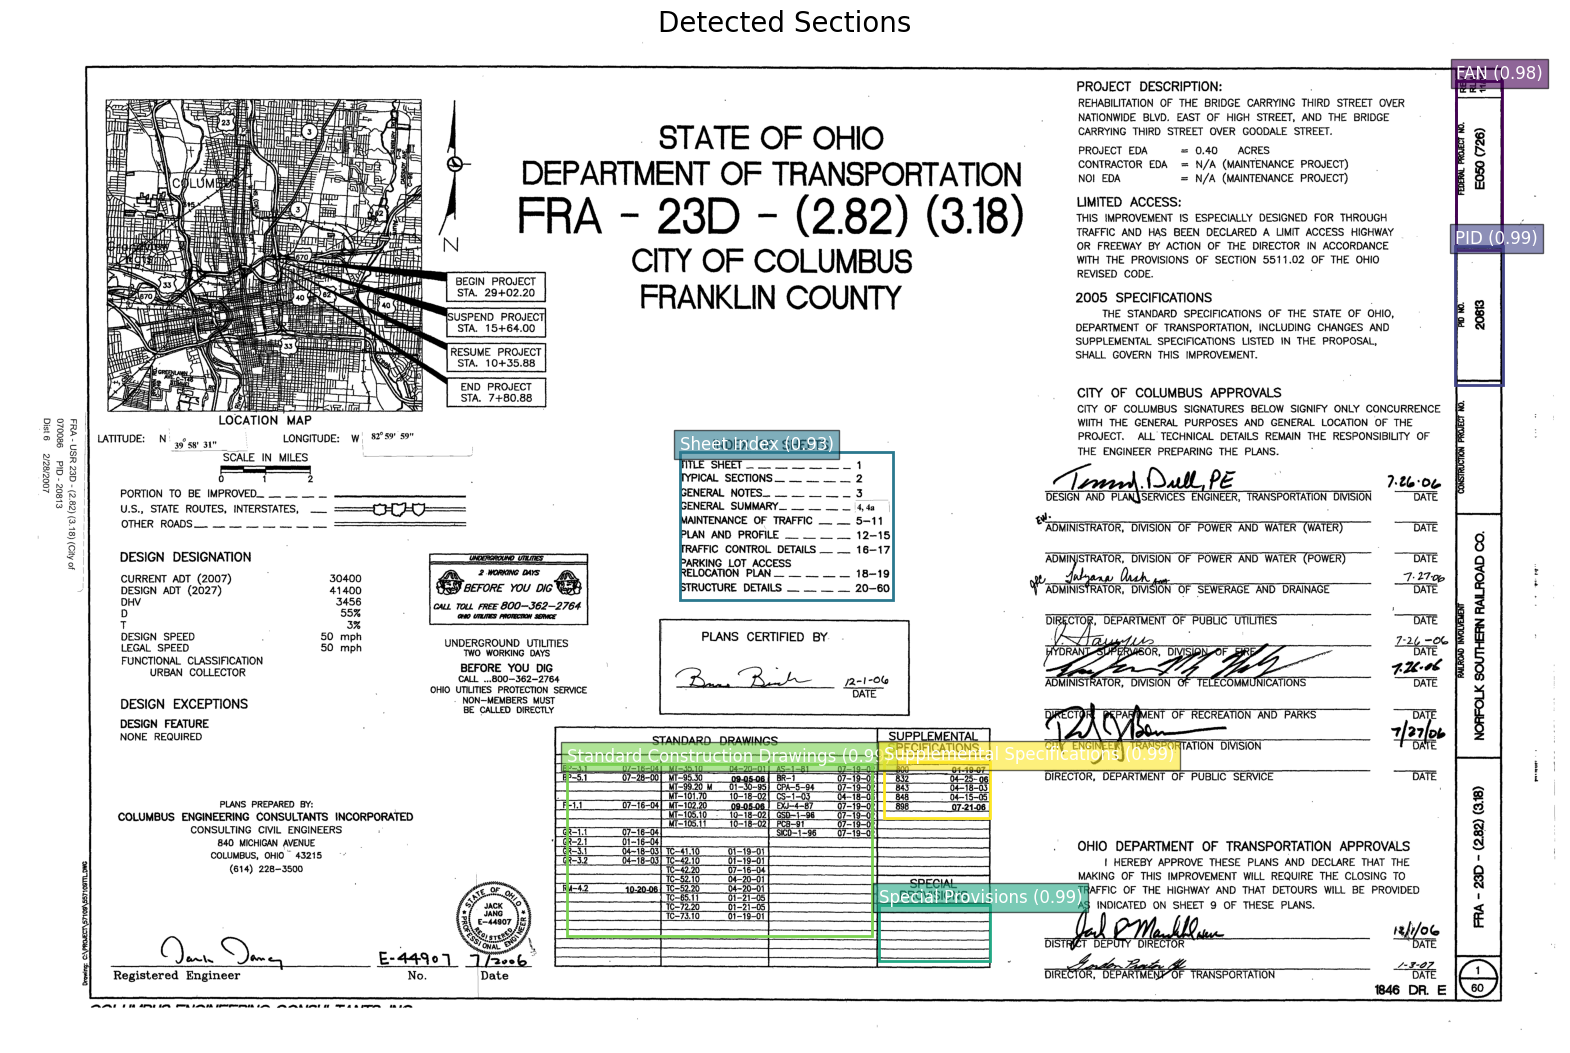

In [18]:
if not found_sections:
    print("No sections were found in the image. Nothing to display.")
else:
    # Create a figure to draw on
    fig, ax = plt.subplots(1, figsize=(20, 25))
    ax.imshow(image)

    # Create a color map for different labels
    # Using a modern colormap that is perceptually uniform.
    colors = plt.get_cmap('viridis', len(DISCOVERED_LABELS))
    color_map = {label: colors(i) for i, label in enumerate(DISCOVERED_LABELS)}

    # Draw each found bounding box
    for section in found_sections:
        box = section['box']
        label = section['label']
        score = section['score']
        color = color_map[label]
        
        # Get box coordinates
        xmin, ymin, xmax, ymax = box
        width = xmax - xmin
        height = ymax - ymin

        # Create a rectangle patch
        rect = patches.Rectangle(
            (xmin, ymin),
            width, 
            height, 
            linewidth=2, 
            edgecolor=color, 
            facecolor='none'
        )
        ax.add_patch(rect)

        # Add the label and score text
        ax.text(
            xmin, 
            ymin - 10,  # Position text just above the box
            f"{label} ({score:.2f})", 
            color='white',
            fontsize=12, 
            bbox=dict(facecolor=color, alpha=0.6)
        )

    # Display the final image
    plt.axis('off')
    plt.title('Detected Sections', fontsize=20)
    plt.show()